In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

# sklearn packages
from sklearn.preprocessing import (StandardScaler, 
                                    MinMaxScaler)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split

from sklearn.metrics import (accuracy_score, 
                            classification_report, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay)


In [19]:
TRAIN_FILE_PATH = "../data/mne/train.npz"
VALID_FILE_PATH = "../data/mne/valid.npz"
TEST_FILE_PATH = "../data/mne/test.npz"


# Train
train = np.load(TRAIN_FILE_PATH)
X_train, y_train = train["arr_0"], train["arr_1"].astype(int)

# Valid
valid = np.load(VALID_FILE_PATH)
X_valid, y_valid = valid["arr_0"], valid["arr_1"].astype(int)

X, y = np.vstack([X_train, X_valid]), np.hstack([y_train, y_valid])

# Test
test = np.load(TEST_FILE_PATH)
X_test, y_test = test["arr_0"], test["arr_1"].astype(int)

print(f"Shape of X_train : {X_train.shape} and y_train : {y_train.shape}")
print(f"Shape of X_val : {X_valid.shape} and y_valid : {y_valid.shape}")
print(f"Shape of X_test : {X_test.shape} and y_test : {y_test.shape}")

Shape of X_train : (20776, 320) and y_train : (20776,)
Shape of X_val : (3596, 320) and y_valid : (3596,)
Shape of X_test : (3686, 320) and y_test : (3686,)


In [20]:
X = X[(y != 0)]
X_test = X_test[(y_test != 0)]

In [21]:
y = y[(y != 0)]
y_test = y_test[(y_test != 0)]

In [23]:
class Encoder(Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(128, activation='relu')
        self.mu = layers.Dense(latent_dim)
        self.log_var = layers.Dense(latent_dim)

    def call(self, x):
        x = self.flatten(x)
        x = self.dense1(x)
        return self.mu(x), self.log_var(x)

class Sampling(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * epsilon

class Decoder(Model):
    def __init__(self, original_shape):
        super().__init__()
        self.dense1 = layers.Dense(128, activation='relu')
        self.dense2 = layers.Dense(np.prod(original_shape), activation='sigmoid')
        self.reshape = layers.Reshape(original_shape)

    def call(self, z):
        x = self.dense1(z)
        x = self.dense2(x)
        return self.reshape(x)

class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.sampling = Sampling()

    def call(self, x):
        mu, log_var = self.encoder(x)
        z = self.sampling((mu, log_var))
        x_recon = self.decoder(z)
        # VAE Loss
        recon_loss = tf.reduce_mean(tf.keras.losses.mse(x, x_recon)) * np.prod(x.shape[1:])
        kl_loss = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mu) - tf.exp(log_var))
        self.add_loss(recon_loss + kl_loss)
        return x_recon

# -----------------------
# 2. Data Augmentation Function
# -----------------------
def vae_augment(X, y, n_samples=None, latent_dim=10, epochs=30, batch_size=64):
    if n_samples is None:
        n_samples = len(X)

    original_shape = X.shape[1:]
    encoder = Encoder(latent_dim)
    decoder = Decoder(original_shape)
    vae = VAE(encoder, decoder)
    vae.compile(optimizer='adam')

    vae.fit(X, X, epochs=epochs, batch_size=batch_size, verbose=0)

    # Generate new samples
    z_samples = np.random.normal(size=(n_samples, latent_dim))
    X_new = decoder(z_samples).numpy()
    
    # Repeat y to match new samples
    y_new = np.random.choice(y, size=n_samples)  # random sampling of labels

    X_aug = np.concatenate([X, X_new], axis=0)
    y_aug = np.concatenate([y, y_new], axis=0)
    return X_aug, y_aug

In [24]:
X = X[..., np.newaxis]  # add channel dimension

X_aug, y_aug = vae_augment(X, y, n_samples=5000, latent_dim=10, epochs=20)
print("Original:", X.shape, y.shape)
print("Augmented:", X_aug.shape, y_aug.shape)

Original: (12605, 320, 1) (12605,)
Augmented: (17605, 320, 1) (17605,)


In [25]:
X_aug = X_aug.squeeze()

In [26]:
def tune_random_forest_full(X, y, n_iter=20, random_state=42):
    """
    Tune RandomForestClassifier using RandomizedSearchCV on the full dataset
    and return the best model trained on all data.

    Parameters:
    -----------
    X : array-like
        Feature matrix.
    y : array-like
        Target labels.
    n_iter : int, optional
        Number of random parameter combinations to try. Default = 20
    random_state : int, optional
        Seed for reproducibility. Default = 42

    Returns:
    --------
    best_model : RandomForestClassifier
        Random Forest model trained on the full dataset with best hyperparameters.
    """

    # --- Base Random Forest --- #
    rf = RandomForestClassifier(random_state=random_state)

    # --- Parameter space --- #
    param_distributions = {
        'n_estimators': [100],#, 200, 300, 500],
        'max_depth': [None, 10, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
    }

    # --- Randomized Search with 5-fold CV --- #
    rf_random = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=5,                   # cross-validation folds
        verbose=2,
        random_state=random_state,
        n_jobs=-1
    )

    # --- Fit search on full dataset --- #
    rf_random.fit(X, y)

    # --- Return the best model trained on all data --- #
    best_model = rf_random.best_estimator_
    print(rf_random.best_estimator_)
    best_model.fit(X, y)  # retrain on full dataset
    return best_model

best_rf = tune_random_forest_full(X_aug, y_aug, n_iter=2)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   9.4s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   9.6s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  10.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  10.2s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  10.4s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  10.6s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  10.4s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=1

              precision    recall  f1-score   support

           1       0.72      0.77      0.74       503
           2       0.76      0.76      0.76       499
           3       0.77      0.73      0.75       452
           4       0.76      0.74      0.75       452

    accuracy                           0.75      1906
   macro avg       0.75      0.75      0.75      1906
weighted avg       0.75      0.75      0.75      1906



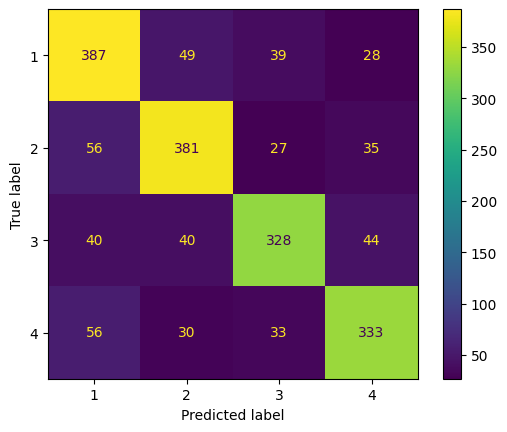

In [27]:
y_test_pred = best_rf.predict(X_test)
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_test_pred))

# SVM Model

In [28]:
print(f"Shape of X augmented: {X_aug.shape}")
print(f"Shape of y augmented: {y_aug.shape}")

Shape of X augmented: (17605, 320)
Shape of y augmented: (17605,)


In [30]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_aug, y_aug)

SVC()

              precision    recall  f1-score   support

           1       0.42      0.52      0.46       503
           2       0.40      0.45      0.42       499
           3       0.51      0.37      0.43       452
           4       0.45      0.38      0.41       452

    accuracy                           0.43      1906
   macro avg       0.44      0.43      0.43      1906
weighted avg       0.44      0.43      0.43      1906



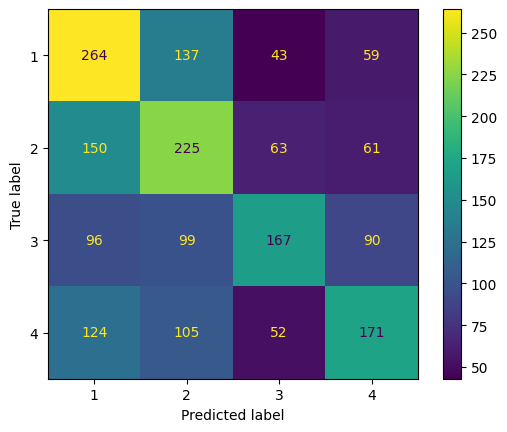

In [31]:
y_test_pred = model.predict(X_test)
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_test_pred))